In [1]:
%pylab inline

# import warnings;
# warnings.filterwarnings('ignore');

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
# from mpl_toolkits.mplot3d import Axes3D

from matplotlib import rc
rc('text', usetex=True)
# rc('font', family='Times New Roman', size='20')
fontsize = 22
params = {
    'font.family': 'Times New Roman',
#     'font.weight': 150,
    'font.size': fontsize,
    'axes.titlesize': fontsize,
    'axes.labelsize': fontsize ,
    'xtick.labelsize': fontsize-2,
    'ytick.labelsize': fontsize-2,
    'legend.fontsize': fontsize-5,
}
rcParams.update(params)

Duplicate key in file '/Users/chigamma/.matplotlib/matplotlibrc' line #2.

Bad key "“backend" on line 2 in
/Users/chigamma/.matplotlib/matplotlibrc.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


Populating the interactive namespace from numpy and matplotlib


In [2]:
import os
import argparse
import re

In [32]:
def geteacc(acc_lst, acc=80):
    for i, v in enumerate(acc_lst):
        if v >= acc:
            break
    return i

def comm(siz_lst, i, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:i+1])
    return res

def commE(siz_lst, cn=10):
    res = 0
    for client in range(cn):
        res += sum(siz_lst[client][:200])
        if len(siz_lst[client]) > 200:
            print("Warning")
    return res

def get_onef(d, f, layer=-3):
    path_save = os.path.join("../../save/", d, f)
    file_log = os.path.join(path_save, 'log.txt')
    print(file_log)
    with open(file_log, 'r') as fil:
        s = fil.read()
    
    loss_lst, acc_lst = [], []
    it = re.finditer(
        r'\[Server\]  Test Loss: (\d+\.\d+),  Accuracy: (\d+\.\d+)', s)
    for i in it:
        loss_lst.append(float(i.group(1)))
        acc_lst.append(100 * float(i.group(2)))
    if len(acc_lst) != 100:
        print("Warning", d, f, len(acc_lst))

    err_lst, rnk_lst = {}, {}
    for client in range(10):
        it = re.finditer(
            r'\[Client  {}\]  MF layer{} Error L2: (\d+\.\d+),  Rank:\s+(\d+)'.format(client, layer), s)
        err_lst[client], rnk_lst[client] = [], []
        for i in it:
            err_lst[client].append(float(i.group(1)))
            rnk_lst[client].append(int(i.group(2)))
    
#     siz_lst = {}
#     for client in range(10):
#         it = re.finditer(
#             r'\[Client  {}\]  Param Before: \d+\.\d+e\+\d+,  After: (\d+\.\d+e\+\d+)'.format(client), s)
#         siz_lst[client] = []
#         for i in it:
#             siz_lst[client].append(float(i.group(1)))
            
#     comm_lst = [0]
#     for i in range(200):
#         comm = comm_lst[i]
#         for c in range(10):
#             comm += siz_lst[c][i]
#         comm_lst.append(comm)
    
    dic = {'f': f,
           'loss': [max(loss_lst)]+loss_lst,
           'acc': [10]+acc_lst,
#            'siz': siz_lst,
#            'comm': comm_lst,
           'err': err_lst,
           'rnk': rnk_lst}
    return dic

In [42]:
issave = True

In [48]:
d = {}
drr = 'AlsAvg'
flst = ['0717-c0f704', '0729-b3aea8', '0716-9faac9', '0716-6fe36e', '0716-3dc46e'] 
nlst = ['102', '105', '110', '115', '120',] 
llst = [-3, 1, -3, -3, -3, ]
for f, n, l in zip(flst, nlst, llst):
    d[n] = get_onef(drr, f, l)

../../save/AlsAvg/0717-c0f704/log.txt
Warning AlsAvg 0717-c0f704 200
../../save/AlsAvg/0729-b3aea8/log.txt
../../save/AlsAvg/0716-9faac9/log.txt
Warning AlsAvg 0716-9faac9 200
../../save/AlsAvg/0716-6fe36e/log.txt
Warning AlsAvg 0716-6fe36e 200
../../save/AlsAvg/0716-3dc46e/log.txt
Warning AlsAvg 0716-3dc46e 200


In [49]:
cm = plt.cm.tab20(np.arange(0, 20))
st = {'ls': '-', 'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 25, 'alpha': 0.85}
sp = {'ls': '-', 'lw': 2  , 'alpha': 0.5}

# lb1 = ['$\\mathrm{FedASI}\; k=16$',
#      '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=0.2}$',
#      '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=0.5}$',
#      '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=1.0}$',
#       '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=2.0}$']

lb1 = ['FedASI $k=16$', 
       'FedALS $\\lambda=0.2$',
       'FedALS $\\lambda=0.5$',
       'FedALS $\\lambda=1.0$',
       'FedALS $\\lambda=2.0$',]

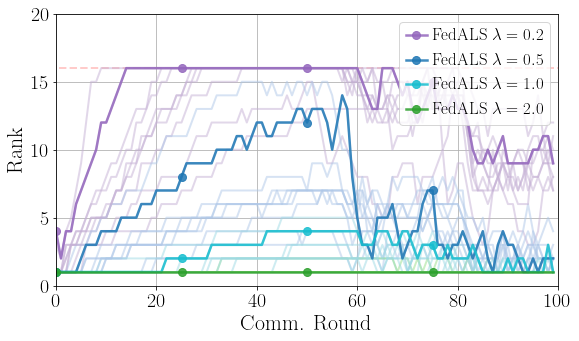

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

x = [i for i in range(0, 100)]

ax.plot([-10, 120], [16, 16], c=cm[7] , ls='--', lw=2, alpha=0.5)
for c in range(0, 10):
    l10 = ax.plot(x, d['102']['rnk'][c][:100], c=cm[9] , **sp)
    l11 = ax.plot(x, d['105']['rnk'][c][:100], c=cm[1] , **sp)
    l12 = ax.plot(x, d['110']['rnk'][c][:100], c=cm[19], **sp)
    l13 = ax.plot(x, d['120']['rnk'][c][:100], c=cm[5] , **sp)

c = 4
l0 = ax.plot(x, d['102']['rnk'][c][:100], c=cm[8] , label=lb1[1], **st)
l1 = ax.plot(x, d['105']['rnk'][c][:100], c=cm[0] , label=lb1[2], **st)
l2 = ax.plot(x, d['110']['rnk'][c][:100], c=cm[18], label=lb1[3], **st)
l2 = ax.plot(x, d['120']['rnk'][c][:100], c=cm[4] , label=lb1[4], **st)

ax.set(xlim=[0, 100], ylim=[0, 20], 
       xlabel='Comm. Round', ylabel='Rank')
ax.grid(True, which='both', axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=1, loc=1, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5alsper_rk16Vrd_cnn.pdf', bbox_inches='tight')

In [39]:
d2 = {}
drr = 'AlsAvg'
flst = [0, 1, 2, 3] 
nlst = ['l0', 'l1', 'l2', 'l3',] 
for f, n in zip(flst, nlst):
    d2[n] = get_onef(drr, '0729-b3aea8', f)

../../save/AlsAvg/0729-b3aea8/log.txt
../../save/AlsAvg/0729-b3aea8/log.txt
../../save/AlsAvg/0729-b3aea8/log.txt
../../save/AlsAvg/0729-b3aea8/log.txt


In [51]:
cm = plt.cm.tab20(np.arange(0, 20))
st = {'ls': '-', 'lw': 2.5, 'marker': 'o', 'ms': 8, 'markevery': 25, 'alpha': 0.85}
sp = {'ls': '-', 'lw': 2  , 'alpha': 0.5}

# lb1 = ['$\\mathrm{FedASI}\; k=16$',
#      '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=0.2}$',
#      '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=0.5}$',
#      '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=1.0}$',
#       '$\\mathrm{FedALS}^{\\;r=16}_{\\,\\lambda=2.0}$']

lb1 = ['FedASI $k=16$', 
       'FedALS Conv1',
       'FedALS Conv2',
       'FedALS FC1',
       'FedALS FC2',]

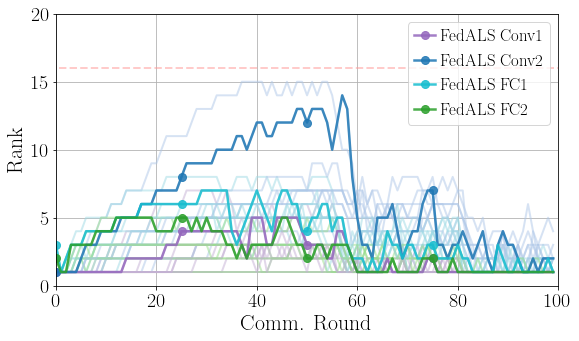

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

x = [i for i in range(0, 100)]

ax.plot([-10, 120], [16, 16], c=cm[7] , ls='--', lw=2, alpha=0.5)
for c in range(0, 10):
    l10 = ax.plot(x, d2['l0']['rnk'][c][:100], c=cm[9] , **sp)
    l11 = ax.plot(x, d2['l1']['rnk'][c][:100], c=cm[1] , **sp)
    l12 = ax.plot(x, d2['l2']['rnk'][c][:100], c=cm[19], **sp)
    l13 = ax.plot(x, d2['l3']['rnk'][c][:100], c=cm[5] , **sp)

c = 4
l0 = ax.plot(x, d2['l0']['rnk'][c][:100], c=cm[8] , label=lb1[1], **st)
l1 = ax.plot(x, d2['l1']['rnk'][c][:100], c=cm[0] , label=lb1[2], **st)
l2 = ax.plot(x, d2['l2']['rnk'][c][:100], c=cm[18], label=lb1[3], **st)
l2 = ax.plot(x, d2['l3']['rnk'][c][:100], c=cm[4] , label=lb1[4], **st)

ax.set(xlim=[0, 100], ylim=[0, 20], 
       xlabel='Comm. Round', ylabel='Rank')
ax.grid(True, which='both', axis='y')
ax.grid(True, which='both', axis='x')

ax.legend(ncol=1, loc=1, 
          columnspacing=0.6, handlelength=1.2, handletextpad=0.3)
if issave:
    fig.savefig('./figs/fig_5alsper_rklVrd_cnn.pdf', bbox_inches='tight')